# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [1]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Carregando o dataset

In [2]:
tamanho_dataset = 10000

In [3]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"dataset_big/sample_{i}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [4]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[0.0, 0.00067138671875, 0.00054931640625, -6.1..."
1,"[0.0, 6.103515625e-05, 0.000244140625, 0.00027..."
2,"[0.0, 6.103515625e-05, 0.000213623046875, 0.00..."
3,"[0.0, 6.103515625e-05, 0.000244140625, 0.00024..."
4,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562..."


### Lendo o alvo

In [5]:
with open("dataset_big/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,0,3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
1,1,2417.237,0.888,0.089,0.048,0.168,0.166,0.580,0.057,0.780,...,0.626,0.208,0.834,0.263,0.471,0.352,0.124,0.017,0.423,0.021
2,2,2441.183,0.180,0.768,0.069,0.511,0.653,0.064,0.932,0.588,...,0.420,0.803,0.266,0.410,0.444,0.234,0.094,0.030,0.050,0.050
3,3,2655.831,0.752,0.622,0.686,0.462,0.642,0.305,0.059,0.452,...,0.779,0.541,0.431,0.045,0.728,0.437,0.162,0.094,0.158,0.087
4,4,3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171


In [6]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,0.853,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
1,2417.237,0.888,0.089,0.048,0.168,0.166,0.580,0.057,0.780,0.078,...,0.626,0.208,0.834,0.263,0.471,0.352,0.124,0.017,0.423,0.021
2,2441.183,0.180,0.768,0.069,0.511,0.653,0.064,0.932,0.588,0.934,...,0.420,0.803,0.266,0.410,0.444,0.234,0.094,0.030,0.050,0.050
3,2655.831,0.752,0.622,0.686,0.462,0.642,0.305,0.059,0.452,0.722,...,0.779,0.541,0.431,0.045,0.728,0.437,0.162,0.094,0.158,0.087
4,3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,0.880,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171


### Juntando alvo e features

In [7]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[0.0, 0.00067138671875, 0.00054931640625, -6.1...",3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
1,"[0.0, 6.103515625e-05, 0.000244140625, 0.00027...",2417.237,0.888,0.089,0.048,0.168,0.166,0.580,0.057,0.780,...,0.626,0.208,0.834,0.263,0.471,0.352,0.124,0.017,0.423,0.021
2,"[0.0, 6.103515625e-05, 0.000213623046875, 0.00...",2441.183,0.180,0.768,0.069,0.511,0.653,0.064,0.932,0.588,...,0.420,0.803,0.266,0.410,0.444,0.234,0.094,0.030,0.050,0.050
3,"[0.0, 6.103515625e-05, 0.000244140625, 0.00024...",2655.831,0.752,0.622,0.686,0.462,0.642,0.305,0.059,0.452,...,0.779,0.541,0.431,0.045,0.728,0.437,0.162,0.094,0.158,0.087
4,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562...",3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171


In [8]:
ds.shape

(10000, 22)

## Separando treino e teste

In [9]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [10]:
train.head(5)

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
9394,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562...",3899.576,0.278,0.954,0.239,0.699,0.805,0.061,0.634,0.233,...,0.855,0.537,0.062,0.740,0.486,0.021,0.112,0.015,0.342,0.182
898,"[0.0, 0.00018310546875, 0.000335693359375, -0....",3730.258,0.791,0.909,0.081,0.550,0.809,0.239,0.618,0.633,...,0.026,0.551,0.319,0.280,0.615,0.688,0.136,0.062,0.285,0.093
2398,"[0.0, 3.0517578125e-05, 9.1552734375e-05, -6.1...",3873.587,0.935,0.560,0.359,0.690,0.638,0.573,0.193,0.400,...,0.206,0.278,0.600,0.484,0.016,0.210,0.158,0.078,0.454,0.040
5906,"[0.0, 0.000244140625, 0.00067138671875, 0.0004...",3111.221,0.372,0.941,0.805,0.048,0.959,0.524,0.940,0.096,...,0.611,0.933,0.796,0.999,0.014,0.559,0.073,0.036,0.490,0.088
2343,"[0.0, 0.0003662109375, 0.0003662109375, -0.000...",3827.110,0.891,0.916,0.126,0.939,0.991,0.138,0.217,0.674,...,0.541,0.346,0.627,0.907,0.788,0.581,0.067,0.038,0.075,0.174


In [11]:
x = pd.DataFrame(train[0])
x.head()

,0
9394,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562..."
898,"[0.0, 0.00018310546875, 0.000335693359375, -0...."
2398,"[0.0, 3.0517578125e-05, 9.1552734375e-05, -6.1..."
5906,"[0.0, 0.000244140625, 0.00067138671875, 0.0004..."
2343,"[0.0, 0.0003662109375, 0.0003662109375, -0.000..."


In [12]:
x = np.array(x[0].values.tolist())
x[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [13]:
len(x[0])

22050

In [14]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
9394,3899.576,0.278,0.954,0.239,0.699,0.805,0.061,0.634,0.233,0.856,...,0.855,0.537,0.062,0.740,0.486,0.021,0.112,0.015,0.342,0.182
898,3730.258,0.791,0.909,0.081,0.550,0.809,0.239,0.618,0.633,0.153,...,0.026,0.551,0.319,0.280,0.615,0.688,0.136,0.062,0.285,0.093
2398,3873.587,0.935,0.560,0.359,0.690,0.638,0.573,0.193,0.400,0.213,...,0.206,0.278,0.600,0.484,0.016,0.210,0.158,0.078,0.454,0.040
5906,3111.221,0.372,0.941,0.805,0.048,0.959,0.524,0.940,0.096,0.528,...,0.611,0.933,0.796,0.999,0.014,0.559,0.073,0.036,0.490,0.088
2343,3827.110,0.891,0.916,0.126,0.939,0.991,0.138,0.217,0.674,0.253,...,0.541,0.346,0.627,0.907,0.788,0.581,0.067,0.038,0.075,0.174


In [15]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y)
print(y_train_norm)

[[ 1.54428412 -0.79559244  1.59115002 ... -1.24592491  0.60393865
   1.40526108]
 [ 1.25215641  0.99306068  1.43377971 ...  0.39824316  0.20906926
  -0.1428686 ]
 [ 1.49944478  1.49513875  0.2132855  ...  0.95795995  1.37982236
  -1.06478851]
 ...
 [-1.28500753  1.59973834 -0.89879805 ...  1.09788915 -1.13487218
  -0.28202632]
 [-0.67261905  1.29291286  1.46875089 ...  0.85301305 -0.80927812
   1.47483994]
 [-1.03511048 -1.30813047 -0.96524329 ... -0.05652673  0.93646024
  -1.60402469]]


### Redimensionando a entrada

In [16]:
print(x.shape)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

print(x[0])

# frame_length = 2048

# dataset = []
# for sample in x:
#   length = sample.shape[0]
#   num_frames = int(length / frame_length)
#   amostras_uteis = num_frames * frame_length
#   sample_cutted = sample[:amostras_uteis]
#   sample_cutted = sample_cutted.reshape(num_frames, frame_length)
#   dataset.append(sample_cutted)

# x = np.array(dataset)
# print(x.shape)
# x[0:5]

(7500, 22050)
(7500, 22050, 1)
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


## Construindo o modelo

In [17]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D, Flatten, Dropout, MaxPooling1D, GlobalAveragePooling1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2025-08-24 20:24:30.126645: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-24 20:24:30.451381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756077870.559659    5143 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756077870.588754    5143 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756077870.844181    5143 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [18]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [19]:
print(tf.sysconfig.get_build_info()['cuda_version'])
print(tf.sysconfig.get_build_info()['cudnn_version'])

12.5.1
9


In [20]:
import tensorflow as tf

# Lista GPUs disponíveis
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detectadas:", gpus)

if gpus:
    try:
        # Ativa o crescimento dinâmico de memória para evitar pré-alocação total
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memória GPU configurada para crescimento dinâmico.")
    except RuntimeError as e:
        print("Erro ao configurar memória GPU:", e)
else:
    print("Nenhuma GPU detectada.")

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memória GPU configurada para crescimento dinâmico.


In [21]:
input_len, input_dims, output_dims, activation, bias = x.shape[1], x.shape[2], y_train_norm.shape[1], 'relu', False
  
# Camadas de entrada
input_layer = Input(shape=(input_len, input_dims))

x_n = BatchNormalization()(input_layer)
x_n = Dropout(0.2)(x_n)

# Features 1_1
extrator1_1 = Conv1D(
  filters=2,
  kernel_size=5,
  strides=1,
  activation='relu',
  kernel_regularizer="l1",
  use_bias=True,
)
pooling1_1 = MaxPooling1D(pool_size=3)

features1_1 = extrator1_1(x_n)
features_poll_1_1 = pooling1_1(features1_1)

# Features 1_2
extrator1_2 = Conv1D(
  filters=16,
  kernel_size=128,
  strides=16,
  activation='relu',
  kernel_regularizer="l2",
  use_bias=True,
)
pooling1_2 = MaxPooling1D(pool_size=16)

features1_2 = extrator1_2(features_poll_1_1)
features_poll_1_2 = pooling1_2(features1_2)
features_mean1_2 = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(features_poll_1_2)

# Features 2_1
extrator2_1 = Conv1D(
  filters=16,
  kernel_size=128,
  strides=1,
  activation='relu',
  kernel_regularizer="l2",
  use_bias=True,
)
pooling2_1 = MaxPooling1D(pool_size=5)

features2_1 = extrator2_1(x_n)
features_poll_2_1 = pooling2_1(features2_1)

# Features 2_2
extrator2_2 = Conv1D(
  filters=32,
  kernel_size=256,
  strides=16,
  activation='relu',
  kernel_regularizer="l2",
  use_bias=True,
)
pooling2_2 = MaxPooling1D(pool_size=5)

features2_2 = extrator2_2(features_poll_2_1)
features_poll_2_2 = pooling2_2(features2_2)
features_mean2_2 = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(features_poll_2_2)


# Linearizando as features
features_flatten1 = Flatten()(features_mean1_2)
features_flatten2 = Flatten()(features_mean2_2)

# Concatenando as features
features_flatten = Concatenate()([features_flatten1, features_flatten2])

# Montando o regressor
input_dims_regressor = features_flatten.shape[1]

input_layer_regressor = Input(shape=[input_dims_regressor])

x_0 = Dense(int(input_dims_regressor/2), activation=activation, use_bias=bias, kernel_regularizer="l1")(input_layer_regressor)
x_0 = Dropout(0.2)(x_0)
x_2 = Dense(int(input_dims_regressor/3), activation=activation, use_bias=bias)(x_0)
saidas = Dense(output_dims, activation=None, name='regressor_saidas', use_bias=bias, kernel_regularizer="l2")(x_2)

regressao = Model(input_layer_regressor, saidas, name="regressor")

saida = regressao(features_flatten)

model = Model(input_layer, saida, name="regressao")
features = Model(input_layer, features_flatten, name="projecao")

model.compile(optimizer='adamax', loss='mse', metrics=['mae', 'mse', 'mean_absolute_percentage_error'])
# plot_model(model, to_file='modelo.svg', show_shapes=True, show_layer_names=True)

I0000 00:00:1756077873.201206    5143 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2795 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [22]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y_train_norm, epochs=15, validation_split = 0.2, callbacks=[callback])

Epoch 1/15


I0000 00:00:1756077870.461016    5568 service.cc:152] XLA service 0x7faeb4011b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756077870.461039    5568 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-08-24 20:24:30.528820: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756077870.729955    5568 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/188 ━━━━━━━━━━━━━━━━━━━━ 22:45 7s/step - loss: 5.0413 - mae: 0.8813 - mean_absolute_percentage_error: 134.4299 - mse: 1.0372

I0000 00:00:1756077876.486613    5568 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 130ms/step - loss: 2.7329 - mae: 0.8650 - mean_absolute_percentage_error: 101.4587 - mse: 0.9987 - val_loss: 1.3124 - val_mae: 0.8690 - val_mean_absolute_percentage_error: 100.0772 - val_mse: 1.0064
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - loss: 1.0930 - mae: 0.8649 - mean_absolute_percentage_error: 100.0134 - mse: 0.9984 - val_loss: 1.0413 - val_mae: 0.8690 - val_mean_absolute_percentage_error: 100.0039 - val_mse: 1.0064
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - loss: 1.0214 - mae: 0.8649 - mean_absolute_percentage_error: 100.0000 - mse: 0.9984 - val_loss: 1.0209 - val_mae: 0.8690 - val_mean_absolute_percentage_error: 100.0001 - val_mse: 1.0064
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - loss: 1.0084 - mae: 0.8649 - mean_absolute_percentage_error: 100.0000 - mse: 0.9984 - val_loss: 1.0136 - val_mae: 0.8690 - val_mean_absolute_percentage_error: 100.0000 - val_mse: 1.0064
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 18

In [23]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mean_absolute_percentage_error,mse,val_loss,val_mae,val_mean_absolute_percentage_error,val_mse,epoch
10,1.002022,0.864862,100.0,0.998410,1.009983,0.868963,100.0,1.006359,10
11,1.002021,0.864861,100.0,0.998410,1.009944,0.868963,100.0,1.006359,11
12,1.002022,0.864861,100.0,0.998410,1.009976,0.868963,100.0,1.006359,12
13,1.002022,0.864861,100.0,0.998410,1.009917,0.868963,100.0,1.006359,13
14,1.002022,0.864861,100.0,0.998411,1.009974,0.868963,100.0,1.006359,14


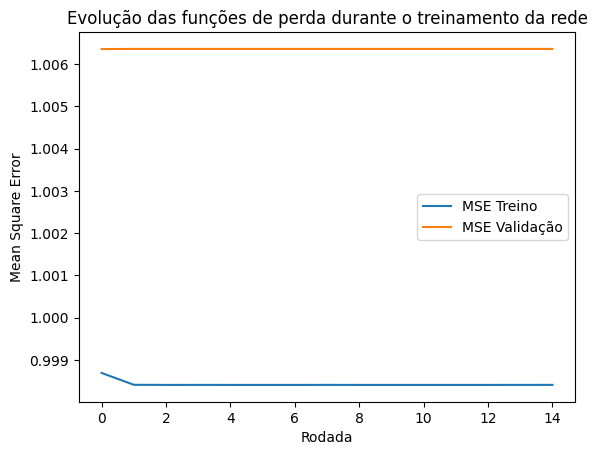

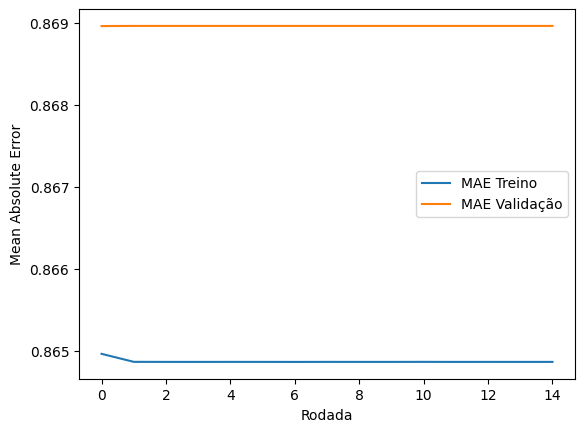

In [24]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Evolução das funções de perda durante o treinamento da rede")
plt.xlabel('Rodada')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Treino')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validação')
plt.legend()

plt.figure()
plt.xlabel('Rodada')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Treino')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validação')
plt.legend()

plt.show()

## Prevendo a amostra de teste

### Ajustando a base de teste

In [25]:
x_t = pd.DataFrame(test[0])
x_t.head()

,0
0,"[0.0, 0.00067138671875, 0.00054931640625, -6.1..."
13,"[0.0, 0.001495361328125, 0.003662109375, 0.002..."
21,"[0.0, 0.000396728515625, 0.00128173828125, 0.0..."
25,"[0.0, 0.00018310546875, 0.00048828125, 0.00042..."
26,"[0.0, 0.000701904296875, 0.0010986328125, -0.0..."


In [26]:
x_t = np.array(x_t[0].values.tolist())
x_t[0]

array([ 0.        ,  0.00067139,  0.00054932, ..., -0.00158691,
       -0.00241089,  0.00076294])

In [27]:
len(x_t[0])

22050

In [28]:
y_t = test.drop(columns=[0])
y_t.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,0.853,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
13,3119.113,0.477,0.451,0.781,0.454,0.613,0.102,0.119,0.269,0.385,...,0.648,0.993,0.338,0.752,0.117,0.835,0.020,0.076,0.494,0.102
21,2194.432,0.178,0.631,0.754,0.860,0.627,0.926,0.249,0.002,0.808,...,0.266,0.069,0.341,0.469,0.426,0.263,0.018,0.013,0.374,0.117
25,2952.863,0.068,0.160,0.021,0.061,0.598,0.076,0.264,0.965,0.322,...,0.786,0.828,0.632,0.943,0.132,0.454,0.082,0.098,0.148,0.022
26,3929.772,0.716,0.794,0.243,0.584,0.590,0.720,0.769,0.671,0.097,...,0.154,0.545,0.791,0.741,0.115,0.952,0.057,0.081,0.008,0.103


### Chamando o modelo para predição

In [29]:
y_pred_norm = model.predict(x_t)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [30]:
y_pred = scaler_y.inverse_transform(y_pred_norm)

In [31]:
y_pred = pd.DataFrame(y_pred)
y_pred.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,3004.504883,0.506182,0.499011,0.498521,0.497155,0.497401,0.498823,0.50562,0.503227,0.496394,...,0.503796,0.496106,0.501284,0.502088,0.50215,0.503603,0.100492,0.050616,0.254821,0.101213
1,3004.504883,0.506182,0.499011,0.498521,0.497155,0.497401,0.498823,0.50562,0.503227,0.496394,...,0.503796,0.496106,0.501284,0.502088,0.50215,0.503603,0.100492,0.050616,0.254821,0.101213
2,3004.504883,0.506182,0.499011,0.498521,0.497155,0.497401,0.498823,0.50562,0.503227,0.496394,...,0.503796,0.496106,0.501284,0.502088,0.50215,0.503603,0.100492,0.050616,0.254821,0.101213
3,3004.504883,0.506182,0.499011,0.498521,0.497155,0.497401,0.498823,0.50562,0.503227,0.496394,...,0.503796,0.496106,0.501284,0.502088,0.50215,0.503603,0.100492,0.050616,0.254821,0.101213
4,3004.504883,0.506182,0.499011,0.498521,0.497155,0.497401,0.498823,0.50562,0.503227,0.496394,...,0.503796,0.496106,0.501284,0.502088,0.50215,0.503603,0.100492,0.050616,0.254821,0.101213


### Calculando erro de teste

In [32]:
mse = tf.keras.losses.MSE(y_t, y_pred).numpy().mean()
mae = tf.keras.losses.MAE(y_t, y_pred).numpy().mean()
rmse = np.sqrt(mse)

In [33]:
print(f"RMSE Test: {rmse}")
print(f"MSE Test: {mse}")
print(f"MAE Test: {mae}")

RMSE Test: 125.38623809814453
MSE Test: 15721.708984375
MAE Test: 23.878206253051758
